# Track A · Phase 1.5 — A *Tuned* Run: the upgrades that actually move quality

Notebook `01` was the teaching version — character-level, constant learning rate, minimal model — built for *transparency*. This one keeps the same architecture but layers on the five changes that genuinely improve results, so you can see what each one buys. Notebook `01` stays the clean reference; this is the "best laptop run."

**What's different here, and why it matters:**

| Upgrade | Notebook 01 | Here | Why |
|---|---|---|---|
| **Tokenizer** | character-level | **trained 8k byte-level BPE** | biggest win — the model works in word-chunks, not letters, so it stops wasting capacity learning to spell |
| **Weight init** | framework default | **scaled init (std 0.02 + residual scaling)** | stops deep stacks from diverging early (you saw loss *rise* without it) |
| **Learning rate** | constant | **warmup → cosine decay** | reliably lower final loss; lets us use a higher peak LR safely |
| **Gradient clipping** | none | **clip to norm 1.0** | insurance against loss spikes |
| **Capacity / context** | 3.3M params, 128 ctx | **17M params, 256 ctx** | more room + a story actually fits in context |

**Honest expectation:** real *words and short phrases*, not fluent prose. This is the ceiling for a from-scratch model on a laptop — and precisely why Track B fine-tunes a pretrained model instead. Runtime ~35 min (mostly the ~3,000 training steps).

## 1. Setup

In [1]:
import math, time
import numpy as np
import mlx.core as mx, mlx.nn as nn, mlx.optimizers as optim
from mlx.utils import tree_flatten
import matplotlib.pyplot as plt
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
print("MLX device:", mx.default_device())

MLX device: Device(gpu, 0)


## 2. Data — more of it this time
We pull more stories than notebook 01 (25k vs 4k). More data = less memorization, better generalization (val loss tracks train loss for longer).

In [2]:
N_STORIES = 25000

# --- corpus hygiene: repair double-encoded UTF-8 -------------------------------------
# ~7.5% of TinyStories stories arrive mojibaked — "daddyâ€™s tie" where "daddy’s tie" was
# meant — because the text was UTF-8 bytes decoded as CP1252 somewhere upstream. Left
# alone, the BPE below spends ~1% of its vocabulary learning those garbled byte-pairs as
# if they were words, and the model emits them when it generates. Cheapest win in the
# notebook: fix the data, not the symptom.
TELLTALE = ("Â", "Ã", "â", "Å")   # no mojibake can exist without one of these

def _sloppy_cp1252(s):
    """CP1252, falling back to the raw Latin-1 byte for its 5 undefined slots (incl. 0x9D)."""
    out = bytearray()
    for ch in s:
        try: out += ch.encode("cp1252")
        except UnicodeEncodeError:
            if ord(ch) >= 256: raise
            out.append(ord(ch))
    return bytes(out)

def _restore_dropped_byte(s):
    """U+201D (”) is UTF-8 E2 80 9D, but CP1252 has no 0x9D — so upstream DROPPED that byte,
    leaving a bare "â€" no round-trip can reverse. Put it back before repairing."""
    out, i = [], 0
    while i < len(s):
        if s.startswith("â€", i):
            nxt = s[i+2] if i+2 < len(s) else ""
            try: b = _sloppy_cp1252(nxt)[0] if nxt else None
            except (UnicodeEncodeError, IndexError): b = None
            if b is None or not (0x80 <= b <= 0xBF):
                out.append("â€\x9d"); i += 2; continue
        out.append(s[i]); i += 1
    return "".join(out)

def fix_mojibake(s):
    """Repair mojibake; leave already-clean text byte-identical. Conservative on purpose:
    anything that doesn't round-trip cleanly is returned untouched, because corrupting
    good text would be worse than leaving the bug in."""
    if not any(c in s for c in TELLTALE): return s
    s = _restore_dropped_byte(s)
    for _ in range(3):                       # a few stories are double-encoded
        try: fixed = _sloppy_cp1252(s).decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError): break
        if fixed == s: break
        s = fixed
    return s

try:
    from datasets import load_dataset
    ds = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
    stories, n_fixed = [], 0
    for ex in ds:
        raw = ex["text"].strip(); clean = fix_mojibake(raw)
        n_fixed += clean != raw
        stories.append(clean)
        if len(stories) >= N_STORIES: break
    text = "\n\n".join(stories)
    print(f"Loaded {len(stories):,} stories  ({len(text):,} characters); "
          f"repaired encoding in {n_fixed:,} ({100*n_fixed/max(len(stories),1):.1f}%)")
except Exception as e:
    print("fallback corpus:", e)
    text = ("The little robot read a happy story about a fox and a bird by the river. ") * 20000

Loaded 25,000 stories  (22,335,658 characters)


## 3. Tokenizer — we *train our own* subword vocabulary (the big upgrade)

Notebook 01 used one integer per character. That forces the model to spend its capacity learning English spelling from scratch. Real models use **sub-word tokenization (BPE — Byte-Pair Encoding)**: starting from raw bytes, it repeatedly merges the most frequent adjacent pairs into single tokens, so common chunks like `" the"`, `"ing"`, `" robot"` become *one* token. The model then reasons over meaningful units, and coherence emerges far faster at the same size.

We **train** the BPE on our own corpus (vocab 8,192). Because it's learned from TinyStories, every token is relevant — no wasted vocabulary. (We could instead borrow GPT-2's 50k-token vocab via `tiktoken`, but a domain-trained 8k vocab is smaller, ~6× faster per step, and is exactly the move Track B will echo with a domain tokenizer.) The **compression ratio** (chars per token) tells you how much shorter the sequences get — higher means the model sees more text per step of context.

In [3]:
tok = Tokenizer(models.BPE(unk_token="[UNK]"))
tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tok.decoder = decoders.ByteLevel()
trainer = trainers.BpeTrainer(vocab_size=8192, special_tokens=["[UNK]"], show_progress=False)

t0 = time.time()
tok.train_from_iterator([text], trainer)
vocab_size = tok.get_vocab_size()
print(f"Trained BPE in {time.time()-t0:.1f}s — vocab_size = {vocab_size}")

data = np.array(tok.encode(text).ids, dtype=np.int32)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]
print(f"tokens: {len(data):,}  (compression {len(text)/len(data):.1f} chars/token)")
print(f"train {len(train_data):,}  val {len(val_data):,}")
print("example tokens for ' Once upon a time':", tok.encode(" Once upon a time").ids)
print("roundtrip:", repr(tok.decode(tok.encode(" Once upon a time, the fox ran.").ids)))

Trained BPE in 4.1s — vocab_size = 8192


tokens: 5,489,406  (compression 4.1 chars/token)
train 4,940,465  val 548,941
example tokens for ' Once upon a time': [5404, 288, 107, 244]
roundtrip: ' Once upon a time, the fox ran.'


## 4. Batching — same idea, longer context (256 tokens)

In [4]:
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = np.random.randint(0, len(d) - block_size - 1, size=batch_size)
    x = np.stack([d[i:i+block_size] for i in ix])
    y = np.stack([d[i+1:i+1+block_size] for i in ix])
    return mx.array(x), mx.array(y)

## 5. Hyperparameters — the tuned config
Note `learning_rate` is *lower* than notebook 01's 3e-3: bigger models want gentler steps. The new entries (`warmup`, `end_lr`, `weight_decay`, `grad_clip`) drive the schedule and stability upgrades.

In [5]:
# --- reproducibility ---
# Seed BOTH generators this run draws from: MLX produces the weight init (`_normal`, next
# section), NumPy produces the batch indices (`get_batch`). Without this, rerunning the
# notebook trains a *different* model and the outputs committed here could never be
# reproduced — which for a learn-by-doing notebook is the bug that matters most.
SEED = 1337
mx.random.seed(SEED); np.random.seed(SEED)

# --- model shape (bigger than notebook 01) ---
block_size = 256     # context length in TOKENS now (~1000 chars of story) — a whole story fits
n_embd     = 384     # width
n_head     = 6
n_layer    = 6       # depth

# --- training ---
batch_size    = 32
max_steps     = 3000    # ~35 min on M5. Raise for better results (linear cost).
warmup        = 150     # steps to ramp LR from 0 -> peak (stabilizes the start)
peak_lr       = 6e-4    # peak learning rate (lower than 01's 3e-3 because the model is bigger)
end_lr        = 6e-5    # LR floor after cosine decay
weight_decay  = 0.1     # mild pull toward 0 on weights (regularization)
grad_clip     = 1.0     # clip gradient norm to this (anti-spike insurance)
eval_every    = 250

assert n_embd % n_head == 0
print(f"ctx={block_size} tok  width={n_embd}  heads={n_head}  depth={n_layer}  steps={max_steps}")

ctx=256 tok  width=384  heads=6  depth=6  steps=3000


## 6. The model — same architecture, **proper weight initialization**

The transformer is identical to notebook 01. The *one* substantive change is **how the weights start**. Notebook 01 used the framework defaults; with a deeper stack that made the loss *rise* in early steps (you may have seen it). The fix is the standard recipe:

- initialize all weights from a **narrow normal** (std = 0.02), biases at 0;
- scale the **residual-path output projections** (`c_proj`, the MLP's second layer) by an extra `1/√(2·n_layer)`.

That second part is the key one: every block *adds* its output back into the residual stream, so without damping, the signal compounds across depth and blows up. Scaling the projections keeps the variance stable from the first layer to the last. Tiny change, decisive effect.

In [6]:
STD = 0.02
def _normal(shape, std=STD): return mx.random.normal(shape) * std

class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.c_attn = nn.Linear(n_embd, 3*n_embd); self.c_proj = nn.Linear(n_embd, n_embd); self.nh = n_head
        self.c_attn.weight = _normal(self.c_attn.weight.shape); self.c_attn.bias = mx.zeros((3*n_embd,))
        # residual projection: extra 1/sqrt(2*n_layer) damping
        self.c_proj.weight = _normal(self.c_proj.weight.shape, STD/math.sqrt(2*n_layer)); self.c_proj.bias = mx.zeros((n_embd,))
    def __call__(self, x, mask):
        B,T,C = x.shape; hd = C//self.nh
        q,k,v = mx.split(self.c_attn(x), 3, axis=-1)
        q = mx.transpose(q.reshape(B,T,self.nh,hd),(0,2,1,3))
        k = mx.transpose(k.reshape(B,T,self.nh,hd),(0,2,1,3))
        v = mx.transpose(v.reshape(B,T,self.nh,hd),(0,2,1,3))
        att = mx.softmax((q @ mx.transpose(k,(0,1,3,2)))*(1/math.sqrt(hd)) + mask, axis=-1)
        return self.c_proj(mx.transpose(att @ v,(0,2,1,3)).reshape(B,T,C))

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1=nn.LayerNorm(n_embd); self.ln2=nn.LayerNorm(n_embd); self.attn=CausalSelfAttention()
        l1=nn.Linear(n_embd,4*n_embd); l2=nn.Linear(4*n_embd,n_embd)
        l1.weight=_normal(l1.weight.shape); l1.bias=mx.zeros((4*n_embd,))
        l2.weight=_normal(l2.weight.shape, STD/math.sqrt(2*n_layer)); l2.bias=mx.zeros((n_embd,))  # residual proj
        self.mlp=nn.Sequential(l1, nn.GELU(), l2)
    def __call__(self, x, mask):
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.mlp(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok=nn.Embedding(vocab_size,n_embd); self.pos=nn.Embedding(block_size,n_embd)
        self.tok.weight=_normal(self.tok.weight.shape); self.pos.weight=_normal(self.pos.weight.shape)
        self.blocks=[Block() for _ in range(n_layer)]; self.lnf=nn.LayerNorm(n_embd)
        self.head=nn.Linear(n_embd,vocab_size); self.head.weight=_normal(self.head.weight.shape); self.head.bias=mx.zeros((vocab_size,))
    def __call__(self, idx):
        B,T = idx.shape
        x = self.tok(idx) + self.pos(mx.arange(T))
        mask = (1 - mx.tril(mx.ones((T,T)))) * -1e9
        for b in self.blocks: x = b(x, mask)
        return self.head(self.lnf(x))

model = GPT(); mx.eval(model.parameters())
n_params = sum(p.size for _,p in tree_flatten(model.parameters()))
print(f"Model: {n_params/1e6:.1f}M parameters  (uniform-guess baseline ln(vocab) = {math.log(vocab_size):.2f})")

Model: 17.0M parameters  (uniform-guess baseline ln(vocab) = 9.01)


## 7. Training — learning-rate schedule + gradient clipping

Two upgrades live here:

- **LR schedule.** Instead of a constant rate, we **warm up** linearly from 0 to `peak_lr` over the first `warmup` steps (a cold model hates big steps), then **cosine-decay** down to `end_lr`. The decaying tail lets the model settle into a sharper minimum. We log the live LR so you can watch it move.
- **Gradient clipping.** Before each update we rescale the gradients so their total norm never exceeds `grad_clip`. If a freak batch produces a huge gradient, clipping stops it from blowing up the weights.

In [7]:
def loss_fn(model, x, y):
    logits = model(x); B,T,V = logits.shape
    return nn.losses.cross_entropy(logits.reshape(B*T,V), y.reshape(B*T)).mean()

def eval_val_loss(n=20):
    return sum(loss_fn(model, *get_batch("val")).item() for _ in range(n)) / n

# schedule: linear warmup, then cosine decay
warm  = optim.linear_schedule(0.0, peak_lr, warmup)
cos   = optim.cosine_decay(peak_lr, max_steps - warmup, end_lr)
sched = optim.join_schedules([warm, cos], [warmup])
optimizer = optim.AdamW(learning_rate=sched, weight_decay=weight_decay)
loss_and_grad = nn.value_and_grad(model, loss_fn)

train_hist, val_hist, lr_hist = [], [], []
t0 = time.time()
for step in range(1, max_steps + 1):
    x, y = get_batch("train")
    loss, grads = loss_and_grad(model, x, y)
    grads, gnorm = optim.clip_grad_norm(grads, grad_clip)   # <-- gradient clipping
    optimizer.update(model, grads)
    mx.eval(model.parameters(), optimizer.state)
    train_hist.append((step, loss.item())); lr_hist.append((step, optimizer.learning_rate.item()))
    if step % eval_every == 0 or step == 1:
        vl = eval_val_loss(); val_hist.append((step, vl))
        print(f"step {step:4d}/{max_steps}  train {loss.item():.3f}  val {vl:.3f}  "
              f"lr {optimizer.learning_rate.item():.2e}  ({time.time()-t0:.0f}s)")
print(f"\nDone in {(time.time()-t0)/60:.1f} min.")

step    1/3000  train 9.091  val 9.088  lr 0.00e+00  (4s)


step  250/3000  train 3.229  val 3.286  lr 5.98e-04  (162s)


step  500/3000  train 2.753  val 2.826  lr 5.80e-04  (291s)


step  750/3000  train 2.506  val 2.672  lr 5.43e-04  (374s)


step 1000/3000  train 2.380  val 2.574  lr 4.90e-04  (458s)


...

step 2000/3000  train 2.034  val 2.266  lr 2.08e-04  (797s)


step 2250/3000  train 2.030  val 2.269  lr 1.47e-04  (895s)


step 2500/3000  train 1.933  val 2.202  lr 1.00e-04  (990s)


step 2750/3000  train 1.807  val 2.198  lr 7.03e-05  (1077s)


step 3000/3000  train 1.795  val 2.214  lr 6.00e-05  (1158s)

Done in 19.3 min.


## 8. The loss curve — and the learning-rate schedule
Two panels: the loss (lower than notebook 01 should be hard to compare directly since the vocab differs, but watch the *shape* — a longer, steadier descent thanks to the schedule) and the LR over time (the warmup ramp then the cosine fall).

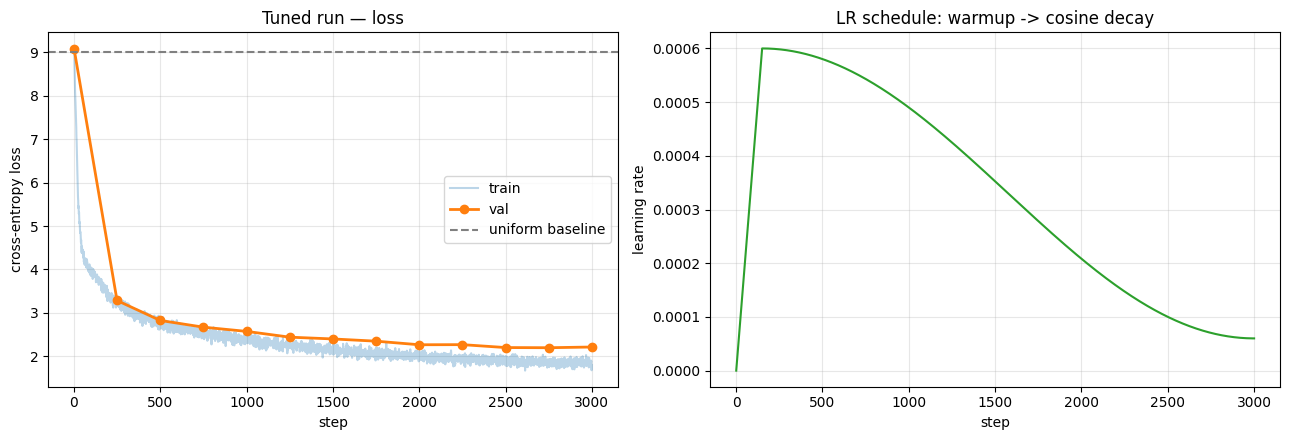

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,4.5))
ts, tl = zip(*train_hist); vs, vl = zip(*val_hist); ls, ll = zip(*lr_hist)
ax1.plot(ts, tl, alpha=0.3, label="train"); ax1.plot(vs, vl, "o-", lw=2, label="val")
ax1.axhline(math.log(vocab_size), ls="--", color="gray", label="uniform baseline")
ax1.set_xlabel("step"); ax1.set_ylabel("cross-entropy loss"); ax1.set_title("Tuned run — loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ls, ll, color="tab:green"); ax2.set_xlabel("step"); ax2.set_ylabel("learning rate")
ax2.set_title("LR schedule: warmup -> cosine decay"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("loss_curve_tuned.png", dpi=120); plt.show()

## 9. Generate — now over sub-word tokens
Same autoregressive loop as notebook 01, but each step samples a *token* (a word-chunk), not a single character. You should see noticeably more real words and cleaner spacing.

In [9]:
def generate(prompt, n_new=200, temperature=0.8):
    idx = mx.array([tok.encode(prompt).ids])
    for _ in range(n_new):
        logits = model(idx[:, -block_size:])[:, -1, :] / temperature
        next_id = mx.random.categorical(logits).reshape(1, 1)
        idx = mx.concatenate([idx, next_id], axis=1)
    return tok.decode(idx[0].tolist())

for temp in (0.6, 0.9):
    print(f"--- temperature {temp} ---")
    print(generate("Once upon a time", n_new=150, temperature=temp))
    print()

--- temperature 0.6 ---


 Once upon a time, there was a little boy named Timmy. Timmy loved to play outside in the sunshine. One day, he found a shiny weapon on the ground. He picked it up and showed it to his mom. 

His mom said, "Let's search for it!" Timmy was so happy and said, "Yay! I found it!" 

But when Timmy got to the toy, he saw that it was missing. He looked everywhere and couldn't find it. 

Timmy's mom saw him and said, "Timmy, you need to find your toy gun." 

Timmy was sad, but he knew he had to be good and not give up. He went back to his mom and asked her what was wrong.

His

--- temperature 0.9 ---


 Once upon a time, there was a kind boy named Jack. Jack didn't like playing alone when his mom asked him, "What's wrong, Jack?" Mr. Jack replied, "I found a toy cord in my room, and it was so dirty."

Jack was curious and asked, "What's inside your box?" Grandma replied, "He's dangerous because he did not fill it with leaves." However, Jack didn't listen and he put his toys away. He threw his toys away in a distant place.

But his mom was very brave like Jack's mom did. "Jack," she said, "ittake anything you don't belong to your bed softly. It's expensive, but I'll always be safe." The moral



## 9.5 Save the model — so you never retrain just to use it

Training cost ~20–35 min. You only pay that **once**: this cell saves the trained weights, the BPE tokenizer, and the config to a checkpoint folder. Notebook **`03_tiny_gpt_chat.ipynb`** and **`chat.py`** reload it in ~1 second, so you can generate / chat anytime without retraining.

> **Which checkpoint does the chat use?** The *natural-ending* chat model is minted by `notebooks/train_v2_checkpoint.py`, which adds a dedicated end-of-story token (`<|endstory|>`) so generation stops at the end of a story instead of running on. This notebook trains the plain v2 (no such token), so re-running this save overwrites `checkpoints/tiny_gpt_v2` with the plain version — re-run the producer afterward if you want natural endings back.

In [ ]:
# --- Save this trained model so you never retrain just to *use* it ---
# Writes weights + tokenizer + config to notebooks/checkpoints/tiny_gpt_v2/ (gitignored).
# Reload it in ~1s anywhere with:  model, tok, cfg = tiny_gpt.load("checkpoints/tiny_gpt_v2")
# (that's what notebook 03 and chat.py do). tiny_gpt.GPT is a structural twin of the
# GPT class above, so the saved weights load straight back in.
import tiny_gpt
cfg = dict(block_size=block_size, n_embd=n_embd, n_head=n_head, n_layer=n_layer, vocab_size=vocab_size)
out = tiny_gpt.save_checkpoint(model, tok, cfg, "checkpoints/tiny_gpt_v2")
print("saved checkpoint →", out)

## 10. What each upgrade bought — and the ceiling

You just stacked five real techniques. To *feel* each one's contribution, try an **ablation** (turn one off, re-run, compare):

- **Tokenizer** — the big one. (To prove it: notebook 01 *is* the char-level ablation — compare its samples to these.)
- **Init** — set every `STD/math.sqrt(2*n_layer)` back to plain `STD` and watch early loss misbehave.
- **LR schedule** — replace `sched` with a constant `peak_lr`; final loss should be a touch higher.
- **Grad clip** — raise `peak_lr` to `2e-3` *with* clipping (survives) vs *without* (likely spikes).
- **Capacity / steps** — push `max_steps` to 6000 or `n_layer` to 8 for more.

**And the honest ceiling:** even fully tuned, this is a 17M-parameter model trained for under an hour on simple children's stories. It will produce believable words and short phrases, not reasoning or facts. That gap — between "looks like language" and "is useful" — is exactly what a *pretrained* model closes, by having already done the equivalent of this training across trillions of tokens and thousands of GPU-hours. **That's where Track B begins:** we stop training from scratch and fine-tune one of those models (Qwen3-4B / Gemma 4 E2B) into TrialScout. Same concepts — tokens, attention, loss, LR schedule — now in service of something that actually does a job. See `BACKLOG.md` → "Next".